# Variational Autoencoders

We want to generate samples from $p(x)$.

Write $p(x) = \int p(x|z)p(z)$ for some hidden variable $z$. The idea is to set $p(z)$ as distribution that can be sampled from (e.g. a multi-dimensional unit normal distribution), and fit a NN model to translate the sample via $p(x|z)$. So far, this is exact.

To create a trainable model some tricks and approximations are used:
- Assume each specific point x comes from a certain region in $z$, which is sampleable (gaussian), and parametrized: $q(z|x) = \mathcal{N}\left(z;\, \mu_\phi(x),\, \sigma^2_\phi(x)\right)$
- Train an encoder model for $\mu(x)$ and $\sigma(x)$, and a decoder model for $p(x|z)$ - the decoder can be used for sampling.
- To train the model, maximize:  $\ln p(x) \geq \mathbb{E}_{q(z|x)}\left[\ln p(x|z)\right] - D_{KL}\left[q(z|x) \| p(z)\right]$ (Expectation Lower Bound, ELBO).
- The loss minimizes the reconstruction error (first term) and penalizes dissimilarity between q and p (second term).
- Instead of calculating expectation values (integrals), use a Monte Carlo approach and just sample from $q(z|x)$. This is better than sampling from $p(z)$ directly, because the region of $q$ is more constrained, and we can sample using the reparameterization trick: $z = \mu(x) + \sigma(x) \epsilon$, where only $\epsilon$ is sampled, and $\mu$ and $\sigma$ are network predictions.



## Toy problem for demo and analysis

We construct a toy dataset of 2D points on the unit circle, with density concentrated around $(0, 1)$ and $(0, -1)$.

By construction, there is a **true latent variable**, which is an angle $z \in [0, 2\pi]$. Observed data is generated as:

$$z \sim \tfrac{1}{2}\mathcal{N}(\pi/2,\, \sigma_z^2) + \tfrac{1}{2}\mathcal{N}(3\pi/2,\, \sigma_z^2), \qquad x = \begin{pmatrix}\cos z \\ \sin z\end{pmatrix} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_{\mathrm{obs}}^2 I)$$

The goal is to learn a VAE that recovers a latent representation close to $z$. This is deliberately difficult for the model: it is fit based on the assumption that there is a unimodal normal distribution on $z$.



Why "variational"? Variational calculus = finding the optimum function wrt a functional (map of a function to a scalar).
Here: the function that is optimized is $q(z|x)$, and the functional the ELBO. In reality, no variational calculus is used:  an encoder network predicts the parameters of q(z|x) for any x, and we optimize only these parameters.

## Reference

- This notebook is partly following one of the great examples from this book:
[Tomczak, J. M. (2024). Deep Generative Modeling. Springer Cham](https://link.springer.com/book/10.1007/978-3-031-64087-2)
- And its [github code](https://github.com/jmtomczak/intro_dgm)

In [13]:
import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from matplotlib import pyplot as plt
import flax.linen as nn
import optax
from flax.training.train_state import TrainState

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# silence some warnings
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [60]:
def sample_data(key, n=2000, sigma_z=0.5, sigma_obs=0.05):
    """Sample n points from the circular two-cluster dataset.

    Latent z ~ equal mixture of N(pi/2, sigma_z) and N(3pi/2, sigma_z), wrapped to [0, 2pi].
    Observed x = (cos z, sin z) + N(0, sigma_obs^2 I).

    Returns:
        x: (n, 2) observed positions
        z: (n,) true latent angles in [0, 2pi]
    """
    k1, k2, k3 = random.split(key, 3)
    components = random.bernoulli(k1, p=0.5, shape=(n,))
    centers = jnp.where(components, 3 * jnp.pi / 2, jnp.pi / 2)
    z_raw = centers + sigma_z * random.normal(k2, shape=(n,))
    z = z_raw % (2 * jnp.pi)
    x_clean = jnp.stack([jnp.cos(z), jnp.sin(z)], axis=-1)
    x = x_clean + sigma_obs * random.normal(k3, shape=(n, 2))
    return x, z


key = random.PRNGKey(0)
sigma_z=0.5
x, z = sample_data(key, sigma_z=sigma_z)
print(f"x shape: {x.shape}, z shape: {z.shape}")

x shape: (2000, 2), z shape: (2000,)


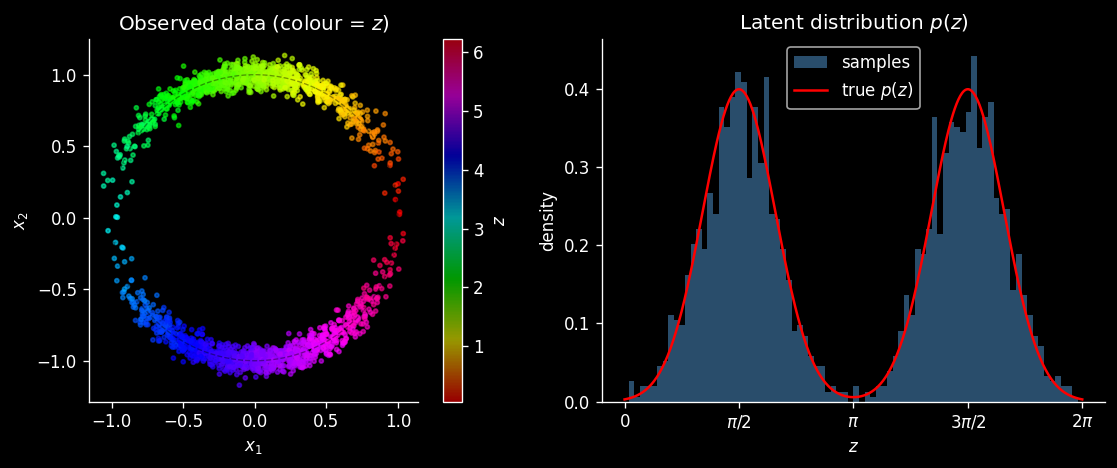

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: observed data coloured by latent angle
ax = axes[0]
sc = ax.scatter(x[:, 0], x[:, 1], c=np.array(z), cmap="hsv", s=6, alpha=0.6)
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, alpha=0.4)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Observed data (colour = $z$)")
plt.colorbar(sc, ax=ax, label="$z$")

# Right: histogram of z with two Gaussian peaks visible
ax = axes[1]
z_np = np.array(z)
ax.hist(z_np, bins=80, density=True, alpha=0.6, color="steelblue", label="samples")
z_grid = np.linspace(0, 2 * np.pi, 500)

density = 0.5 * (
    np.exp(-0.5 * ((z_grid - np.pi / 2) / sigma_z) ** 2)
    + np.exp(-0.5 * ((z_grid - 3 * np.pi / 2) / sigma_z) ** 2)
)
density /= density.sum() * (z_grid[1] - z_grid[0])
ax.plot(z_grid, density, "r-", lw=1.5, label="true $p(z)$")
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_xlabel("$z$")
ax.set_ylabel("density")
ax.set_title("Latent distribution $p(z)$")
ax.legend()

plt.tight_layout()
plt.show()

## Model

Encoder $q_\phi(z \mid x)$: maps $x \in \mathbb{R}^2$ to a Gaussian over the 1-D latent $z$, outputting $(\mu_\phi(x),\, \log\sigma^2_\phi(x))$.

Decoder $p_\theta(x \mid z)$: maps $z \in \mathbb{R}$ to the mean of a Gaussian in $\mathbb{R}^2$ with fixed noise $\sigma_\text{obs}$.

Training objective (ELBO):
$$\mathcal{L} = \mathbb{E}_{q_\phi(z|x)}\!\left[-\frac{\|x - f_\theta(z)\|^2}{2\sigma_\text{obs}^2}\right] - D_\text{KL}\!\left(q_\phi(z|x)\,\|\,\mathcal{N}(0,1)\right)$$

Here, $p(x|z)$ was modeled as a Gaussian with the model output $f_\theta(z)$ as mean. The fixed variance $\sigma_\text{obs}^2$ determines the trade-off between reconstruction error and KL divergence. Essentially this is equivalent to a regression problem with MSE.

In the implementation, $\mathbb{E}_{q_\phi(z|x)}$ will just be replaced by the average across a single sample of $z$.

The KL divergence between two Gaussians has a closed-form solution. For Gaussian diagonal distribution q (with mean $\mu$ and standard deviation $\sigma$) and $p = \mathcal{N}(0, 1)$

 $$D_{KL}(q | p) = \sum_{i=1}^{d} \frac{1}{2}\left(\sigma_i^2 + \mu_i^2 - 1 - \ln\sigma_i^2\right)$$, where the sum is over the hidden factor dimension $d$.

In [56]:
class Encoder(nn.Module):
    hidden_dim: int = 32
    latent_dim: int = 1

    @nn.compact
    def __call__(self, x):
        h = nn.tanh(nn.Dense(self.hidden_dim)(x))
        h = nn.tanh(nn.Dense(self.hidden_dim)(h))
        mu = nn.Dense(self.latent_dim)(h)
        log_var = nn.Dense(self.latent_dim)(h)
        return mu, log_var


class Decoder(nn.Module):
    hidden_dim: int = 32

    @nn.compact
    def __call__(self, z):
        h = nn.tanh(nn.Dense(self.hidden_dim)(z))
        h = nn.tanh(nn.Dense(self.hidden_dim)(h))
        return nn.Dense(2)(h)


class VAE(nn.Module):
    hidden_dim: int = 32
    latent_dim: int = 1

    def setup(self):
        self.encoder = Encoder(hidden_dim=self.hidden_dim, latent_dim=self.latent_dim)
        self.decoder = Decoder(hidden_dim=self.hidden_dim)

    def __call__(self, x, key):
        """
        Model output needed for loss calculation
        """
        mu, log_var = self.encoder(x)
        z = mu + jnp.exp(0.5 * log_var) * random.normal(key, shape=mu.shape)
        return self.decoder(z), mu, log_var

    def encode(self, x):
        return self.encoder(x)

    def generate(self, key, n):
        z = random.normal(key, shape=(n, self.latent_dim))
        return self.decoder(z)

In [57]:
SIGMA_OBS = 0.1  # decoder noise; controls reconstruction vs KL trade-off

def elbo_loss(params, x, key):
    """
    Returns (total_loss, (recon_loss, kl_loss)), all averaged over the batch.
    has_aux=True in value_and_grad uses the first element for gradients.
    """
    x_recon, mu, log_var = model.apply(params, x, key)
    recon = jnp.mean(jnp.sum((x - x_recon) ** 2, axis=-1) / (2 * SIGMA_OBS ** 2))
    kl = jnp.mean(-0.5 * jnp.sum(1.0 + log_var - mu ** 2 - jnp.exp(log_var), axis=-1))
    return recon + kl, (recon, kl)

@jax.jit
def train_step(state, x, key):
    (loss, (recon, kl)), grads = jax.value_and_grad(elbo_loss, has_aux=True)(state.params, x, key)
    return state.apply_gradients(grads=grads), loss, recon, kl

## Training

In [58]:
key, init_key = random.split(key)
model = VAE(hidden_dim=32, latent_dim=1)
params = model.init(init_key, x[:1], init_key)

state = TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=optax.adam(1e-3),
)

n_epochs = 1000
batch_size = 256
history = []

for epoch in range(n_epochs):
    key, perm_key = random.split(key)
    x_perm = x[random.permutation(perm_key, len(x))]
    epoch_loss = epoch_recon = epoch_kl = 0.0
    n_batches = 0
    for i in range(0, len(x), batch_size):
        key, step_key = random.split(key)
        state, loss, recon, kl = train_step(state, x_perm[i : i + batch_size], step_key)
        epoch_loss += float(loss)
        epoch_recon += float(recon)
        epoch_kl += float(kl)
        n_batches += 1
    history.append({"loss": epoch_loss / n_batches, "recon": epoch_recon / n_batches, "kl": epoch_kl / n_batches})
    if (epoch + 1) % 200 == 0:
        e = history[-1]
        print(f"Epoch {epoch+1:4d} | loss = {e['loss']:.3f}  recon = {e['recon']:.3f}  kl = {e['kl']:.3f}")

Epoch  200 | loss = 3.647  recon = 1.110  kl = 2.537
Epoch  400 | loss = 3.289  recon = 0.802  kl = 2.488
Epoch  600 | loss = 3.154  recon = 0.722  kl = 2.432
Epoch  800 | loss = 3.166  recon = 0.767  kl = 2.399
Epoch 1000 | loss = 3.098  recon = 0.692  kl = 2.406


## Results

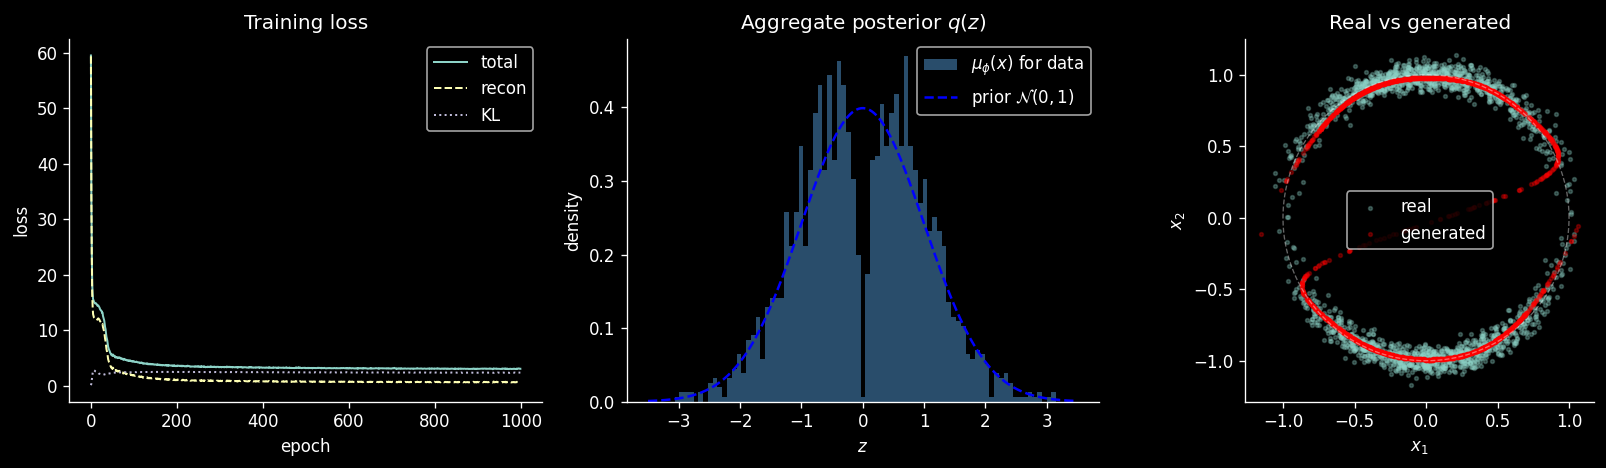

In [59]:
# Encoder means for all training points → aggregate posterior q(z)
mu_q, _ = model.apply(state.params, x, method=VAE.encode)
mu_q = np.array(mu_q[:, 0])

# Generate samples: z ~ N(0,1), then decode
key, gen_key = random.split(key)
x_gen = np.array(model.apply(state.params, gen_key, 2000, method=VAE.generate))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Training loss
ax = axes[0]
ax.plot([e["loss"]  for e in history], lw=1.2, label="total")
ax.plot([e["recon"] for e in history], lw=1.2, label="recon", linestyle="--")
ax.plot([e["kl"]    for e in history], lw=1.2, label="KL",    linestyle=":")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training loss")
ax.legend()

# Aggregate posterior q(z) vs prior N(0,1)
ax = axes[1]
ax.hist(mu_q, bins=80, density=True, alpha=0.6, color="steelblue", label=r"$\mu_\phi(x)$ for data")
z_grid = np.linspace(-3.5, 3.5, 400)
ax.plot(z_grid, np.exp(-0.5 * z_grid**2) / np.sqrt(2 * np.pi),
        "b--", lw=1.5, label=r"prior $\mathcal{N}(0,1)$")
ax.set_xlabel("$z$")
ax.set_ylabel("density")
ax.set_title(r"Aggregate posterior $q(z)$")
ax.legend()

# Real data vs VAE samples
ax = axes[2]
ax.scatter(np.array(x[:, 0]), np.array(x[:, 1]), s=5, alpha=0.3, label="real")
ax.scatter(x_gen[:, 0], x_gen[:, 1], s=5, alpha=0.3, label="generated", color='r')
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "w--", lw=0.8, alpha=0.4)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Real vs generated")
ax.legend()

plt.tight_layout()
plt.show()

### Trainings Loss (left)
- Losses converge; both components contribute to total loss.

###  Encoder maps data to distribution close to prior (middle)
- blue dashed curve: prior $p(z) = \mathcal{N}(0,1)$ (modeling choice).
- histogram: the data samples mapped to z by the encoder. The KL term in the ELBO penalizes mismatch and drives encoder to map data into a shape that resembles the prior.
- 'hole problem': unimodal prior, bimodal data.

### Samples include interpolation between bimodal distribution
- interpolation artifact: encoder needs to map a unimodal prior on z to a continuous sub-manifold in x. Interpolation can be faulty, if there is no data in the region to penalize reconstruction error.
- Why a "Z" shape (and not a "C")? The encoder must map the two dense clusters (top and bottom of the circle) onto a one-d interval in z. Where in x should the point between the clusters (z=0) be mapped? Squared reconstruction error means that at (0, 0) the combined reconstruction error from points to the left and points to the right is smaller than if 0 would be mapped to (0, 1) or (1, 0). The manifold (red curve) must therefore pass through the circle center.


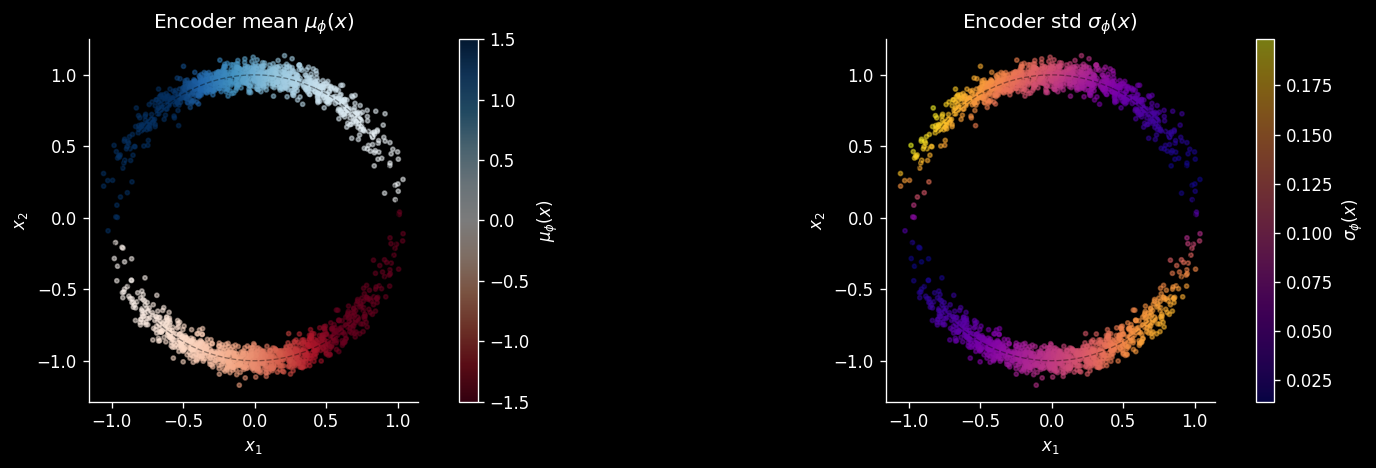

In [62]:
# Encoder mean μ_φ(x) and standard deviation σ_φ(x) across input space
mu_enc, log_var_enc = model.apply(state.params, x, method=VAE.encode)
mu_enc_np    = np.array(mu_enc[:, 0])
sigma_enc_np = np.array(jnp.exp(0.5 * log_var_enc)[:, 0])

theta_circle = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: x coloured by μ_φ(x)
ax = axes[0]
sc = ax.scatter(np.array(x[:, 0]), np.array(x[:, 1]),
                c=mu_enc_np, cmap="RdBu", vmin=-1.5, vmax=1.5,
                s=6, alpha=0.5)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), "k--", lw=0.8, alpha=0.4)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"Encoder mean $\mu_\phi(x)$")
plt.colorbar(sc, ax=ax, label=r"$\mu_\phi(x)$")

# Panel 2: x coloured by σ_φ(x)
ax = axes[1]
sc = ax.scatter(np.array(x[:, 0]), np.array(x[:, 1]),
                c=sigma_enc_np, cmap="plasma",
                s=6, alpha=0.5)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), "k--", lw=0.8, alpha=0.4)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"Encoder std $\sigma_\phi(x)$")
plt.colorbar(sc, ax=ax, label=r"$\sigma_\phi(x)$")


plt.tight_layout()
plt.show()

## Encoder distribution q(z|x)

### Encoder mean $\mu_\phi(x)$ (left)
- Encoder folds circle onto 1-D interval (compare z-shape before)

### Encoder std $\sigma_\phi(x)$ (middle)
- Encoder standard deviation has no clean interpretation as uncertainty from low data density here:  $\sigma$ reflects encoder uncertainty, but uncertainty here is shaped by the decoder's local sensitivity.

